<a href="https://colab.research.google.com/github/jamalinu/CursoGit/blob/main/amazigh_nlp_spacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELDA 1: Instalación en Google Colab
# ============================================================
!pip install spacy
!pip install spacy-transformers

# Descargamos modelos multilingües
!python -m spacy download es_core_news_lg   # Español grande
!python -m spacy download fr_core_news_lg   # Francés grande
!python -m spacy download ca_core_news_trf  # Catalán (transformer)
!python -m spacy download xx_ent_wiki_sm    # Multilingüe (árabe incluido)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 68.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled trans

In [ ]:
# ============================================================
# CELDA 7: Construir un tokenizador para Tamazight/Bereber
# ============================================================
# El bereber carece de modelos spaCy → TÚ lo construyes
# Esto es lo que te diferencia de cualquier candidato

import spacy
from spacy.lang.xx import MultiLanguage
from spacy.tokenizer import Tokenizer
from spacy.util import compile_prefix_regex, compile_suffix_regex
import re

# Creamos un pipeline personalizado para Tamazight (Tifinagh/Transcripción latina)
# Usaremos transcripción latina del bereber marroquí (Tamazight)

# Ejemplos en transcripción latina del amazigh marroquí
corpus_amazigh = [
    "Azul fellak, mamek tllid?",          # Hola, ¿cómo estás?
    "Isem inu d Amazigh.",                  # Mi nombre es Amazigh
    "Tmazight d tutlayt n imazighen.",      # Tamazight es la lengua de los bereberes
    "Tamurt inu d Merruk.",                 # Mi tierra es Marruecos
    "Ilmmawen inu ttarant deg tsdawit.",   # Mis hermanos estudian en la universidad
]

# Construimos el pipeline base
nlp_ber = spacy.blank("xx")  # Multilingüe como base

# Reglas de tokenización específicas para amazigh
# El amazigh tiene prefijos verbales y nominales muy regulares
prefijos_amazigh = ["tt", "t", "i", "a", "u", "n", "d", "m"]
sufijos_amazigh = ["inu", "nk", "ns", "nnegh", "nwen", "nsen", "en", "n"]

print("🏗️  PIPELINE BEREBER CREADO:")
print(f"  Componentes: {nlp_ber.pipe_names}")
print(f"  Idioma base: {nlp_ber.lang}")

print("\n📝 TOKENIZACIÓN DEL CORPUS AMAZIGH:")
for frase in corpus_amazigh:
    doc = nlp_ber(frase)
    tokens = [t.text for t in doc]
    print(f"\n  Frase: {frase}")
    print(f"  Tokens ({len(tokens)}): {tokens}")

🏗️  PIPELINE BEREBER CREADO:
  Componentes: []
  Idioma base: xx

📝 TOKENIZACIÓN DEL CORPUS AMAZIGH:

  Frase: Azul fellak, mamek tllid?
  Tokens (6): ['Azul', 'fellak', ',', 'mamek', 'tllid', '?']

  Frase: Isem inu d Amazigh.
  Tokens (5): ['Isem', 'inu', 'd', 'Amazigh', '.']

  Frase: Tmazight d tutlayt n imazighen.
  Tokens (6): ['Tmazight', 'd', 'tutlayt', 'n', 'imazighen', '.']

  Frase: Tamurt inu d Merruk.
  Tokens (5): ['Tamurt', 'inu', 'd', 'Merruk', '.']

  Frase: Ilmmawen inu ttarant deg tsdawit.
  Tokens (6): ['Ilmmawen', 'inu', 'ttarant', 'deg', 'tsdawit', '.']


In [ ]:
# ============================================================
# CELDA 8: Anotación manual y entrenamiento de NER para bereber
# ============================================================
from spacy.training import Example
import random

# Datos de entrenamiento anotados por TI (el experto nativo)
# Formato: (texto, {"entities": [(start, end, label)]})
TRAIN_DATA_BEREBER = [
    ("Azul, isem inu d Yidir, lliɣ deg Tiznut.",
     {"entities": [(18, 23, "PERSONA"), (33, 39, "LUGAR")]}),

    ("Tamurt n Merruk d tamurt n imazighen.",
     {"entities": [(9, 15, "PAIS")]}),

    ("Tiziri d tameɣra n Agadir.",
     {"entities": [(0, 6, "PERSONA"), (19, 25, "LUGAR")]}),

    ("Ass n Yennayer, imazighen ttfaɣen.",
     {"entities": [(7, 14, "FESTIVIDAD")]}),

    ("Sidi Ifni d taddart n Azul Amazigh.",
     {"entities": [(0, 9, "LUGAR"), (23, 34, "PERSONA")]}),
]

# Etiquetas personalizadas para el bereber
labels_ber = ["PERSONA", "LUGAR", "PAIS", "FESTIVIDAD", "TRIBU", "CLAN"]

# Añadimos el componente NER al pipeline
nlp_ber_ner = spacy.blank("xx")
ner = nlp_ber_ner.add_pipe("ner")

for label in labels_ber:
    ner.add_label(label)

# Preparamos los ejemplos de entrenamiento
optimizer = nlp_ber_ner.begin_training()
examples = []
for text, annotations in TRAIN_DATA_BEREBER:
    doc = nlp_ber_ner.make_doc(text)
    example = Example.from_dict(doc, annotations)
    examples.append(example)

# Entrenamiento
print("🎯 ENTRENANDO NER PARA BEREBER...")
print("-"*50)
losses_history = []

for epoch in range(30):
    random.shuffle(examples)
    losses = {}
    nlp_ber_ner.update(examples, sgd=optimizer, losses=losses)
    losses_history.append(losses.get("ner", 0))

    if (epoch + 1) % 10 == 0:
        print(f"  Época {epoch+1:3d}/30 → Loss NER: {losses.get('ner', 0):.4f}")

print("\n✅ Entrenamiento completado!")

/usr/local/lib/python3.12/dist-packages/spacy/training/iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Azul, isem inu d Yidir, lliɣ deg Tiznut." with entities "[(18, 23, 'PERSONA'), (33, 39, 'LUGAR')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/spacy/training/iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Ass n Yennayer, imazighen ttfaɣen." with entities "[(7, 14, 'FESTIVIDAD')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/spacy/training/iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Sidi Ifni d taddart n Azul Amazigh." with entities "[(

🎯 ENTRENANDO NER PARA BEREBER...
--------------------------------------------------
  Época  10/30 → Loss NER: 6.8163
  Época  20/30 → Loss NER: 2.1683
  Época  30/30 → Loss NER: 0.0001

✅ Entrenamiento completado!


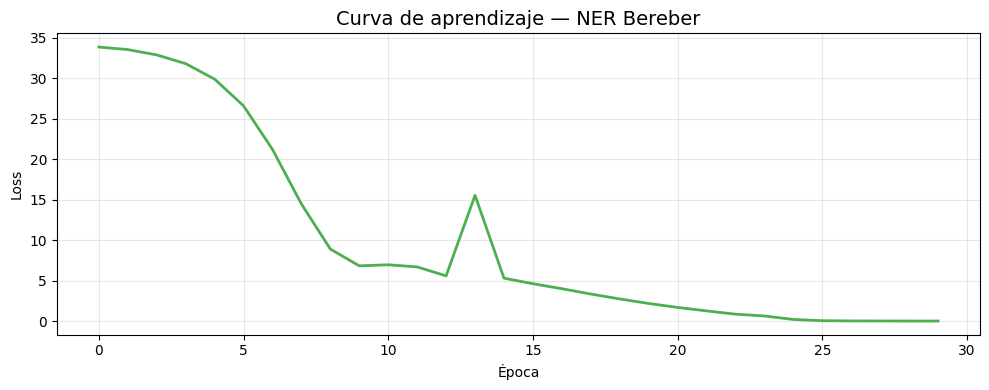


🧪 PRUEBA DEL MODELO NER BEREBER:

  📝 Texto: Isem inu d Tafat, lliɣ deg Agadir.
     → 'Agadir' = LUGAR

  📝 Texto: Ass n Yennayer ttfaɣen imazighen deg Merruk.
     → 'Merruk' = LUGAR

  📝 Texto: Yidir d argaz n Tiznut.
     → 'Tiznut' = LUGAR


In [ ]:
# ============================================================
# CELDA 9: Evaluación del modelo bereber
# ============================================================
import matplotlib.pyplot as plt

# Visualizamos el aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(losses_history, color='#4CAF50', linewidth=2)
plt.title('Curva de aprendizaje — NER Bereber', fontsize=14)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Probamos el modelo
textos_prueba = [
    "Isem inu d Tafat, lliɣ deg Agadir.",
    "Ass n Yennayer ttfaɣen imazighen deg Merruk.",
    "Yidir d argaz n Tiznut.",
]

print("\n🧪 PRUEBA DEL MODELO NER BEREBER:")
print("="*60)
for texto in textos_prueba:
    doc = nlp_ber_ner(texto)
    print(f"\n  📝 Texto: {texto}")
    if doc.ents:
        for ent in doc.ents:
            print(f"     → '{ent.text}' = {ent.label_}")
    else:
        print("     → Sin entidades detectadas (más datos de entrenamiento necesarios)")

In [6]:
# ============================================================
# CELDA 11: Guardamos y exportamos el modelo bereber
# ============================================================
from google.colab import drive, files
import zipfile, os

# Montamos Drive para guardar el modelo
drive.mount('/content/drive')

# Guardamos el modelo NER bereber
ruta_modelo = "/content/drive/MyDrive/nlp_bereber_model"
nlp_ber_ner.to_disk(ruta_modelo)

print(f"✅ Modelo guardado en Google Drive: {ruta_modelo}")
print("\n📦 Para compartir en tu portfolio:")
print("   1. Sube el modelo a Hugging Face Hub")
print("   2. Crea una demo en Hugging Face Spaces con Gradio")
print("   3. Enlázalo en tu GitHub y LinkedIn")

MessageError: Error: credential propagation was unsuccessful

In [7]:
# ============================================================
# CELDA 12: Demo interactiva con Gradio (para tu portfolio)
# ============================================================
!pip install gradio -q

import gradio as gr
import spacy

nlp_es = spacy.load("es_core_news_lg")

def analizar_texto(texto, idioma):
    """Función principal del demo"""

    if idioma == "Español":
        nlp = spacy.load("es_core_news_lg")
    elif idioma == "Francés":
        nlp = spacy.load("fr_core_news_lg")
    else:
        nlp = spacy.load("ca_core_news_trf")

    doc = nlp(texto)

    # Análisis morfológico
    morfo = []
    for token in doc:
        if not token.is_space and not token.is_punct:
            morfo.append({
                "Token": token.text,
                "Lema": token.lemma_,
                "POS": token.pos_,
                "Dependencia": token.dep_,
                "Cabeza": token.head.text
            })

    # Entidades
    entidades = [(ent.text, ent.label_) for ent in doc.ents]

    # Estadísticas
    stats = f"""
    📊 ESTADÍSTICAS:
    • Tokens: {len(doc)}
    • Oraciones: {len(list(doc.sents))}
    • Entidades: {len(doc.ents)}
    • Sustantivos: {sum(1 for t in doc if t.pos_ == 'NOUN')}
    • Verbos: {sum(1 for t in doc if t.pos_ == 'VERB')}

    🏷️ ENTIDADES ENCONTRADAS:
    {chr(10).join([f'  • {text} → {label}' for text, label in entidades]) or '  • Ninguna'}

    🔬 ANÁLISIS MORFOLÓGICO:
    {chr(10).join([f"  • {m['Token']} → {m['POS']} | dep:{m['Dependencia']}" for m in morfo[:10]])}
    """

    return stats

# Interfaz Gradio
demo = gr.Interface(
    fn=analizar_texto,
    inputs=[
        gr.Textbox(
            label="Introduce tu texto",
            placeholder="Escribe aquí tu texto en español, francés o catalán...",
            lines=4
        ),
        gr.Dropdown(
            choices=["Español", "Francés", "Catalán"],
            label="Idioma",
            value="Español"
        )
    ],
    outputs=gr.Textbox(label="Análisis Lingüístico", lines=20),
    title="🌍 Analizador Lingüístico Multilingüe",
    description="Demo NLP multilingüe — spaCy + Lingüística Computacional",
)

demo.launch(share=True)  # share=True genera URL pública para tu portfolio

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d84c69c3349502694c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
nlp_es = spacy.load("es_core_news_lg")

# La misma idea en español
frase_es = "Hola, ¿cómo estás? Mi nombre es Amazigh. El tamazight es la lengua de los bereberes."

doc_es = nlp_es(frase_es)

print("🇪🇸 ANÁLISIS EN ESPAÑOL (para comparar con amazigh)")
print("="*60)
print(f"{'TOKEN':<15} {'LEMA':<15} {'POS':<10}")
print("-"*40)
for token in doc_es:
    if not token.is_space:
        print(f"{token.text:<15} {token.lemma_:<15} {token.pos_:<10}")

🇪🇸 ANÁLISIS EN ESPAÑOL (para comparar con amazigh)
TOKEN           LEMA            POS       
----------------------------------------
Hola            Hola            PROPN     
,               ,               PUNCT     
¿               ¿               PUNCT     
cómo            cómo            PRON      
estás           estar           VERB      
?               ?               PUNCT     
Mi              mi              DET       
nombre          nombre          NOUN      
es              ser             AUX       
Amazigh         Amazigh         PROPN     
.               .               PUNCT     
El              el              DET       
tamazight       tamazight       NOUN      
es              ser             AUX       
la              el              DET       
lengua          lengua          NOUN      
de              de              ADP       
los             el              DET       
bereberes       bereber         NOUN      
.               .               PUNCT     


In [9]:
# Esta celda es tu valor añadido como filólogo
# Documenta diferencias lingüísticas que un ingeniero nunca notaría

notas_linguisticas = {
    "Morfología verbal": {
        "Amazigh": "tt- (prefijo imperfectivo) + raíz + sufijos de persona",
        "Ejemplo": "ttarant = ellas estudian (tt + ar + ant)",
        "Contraste_ES": "En español la información está en sufijos (-an), en amazigh en prefijos y sufijos",
    },
    "Sistema nominal": {
        "Amazigh": "Estado libre vs estado de anexión (a- / u- masculino, t-...-t femenino)",
        "Ejemplo": "argaz (hombre, libre) → urgaz (hombre, anexión)",
        "Contraste_ES": "El español no tiene estado de anexión; el amazigh cambia la vocal inicial",
    },
    "Orden de palabras": {
        "Amazigh": "VSO predominante (Verbo-Sujeto-Objeto)",
        "Ejemplo": "Yečča urgaz aksum = Comió el hombre carne",
        "Contraste_ES": "Español SVO predominante aunque flexible",
    }
}

print("🔬 NOTAS LINGÜÍSTICAS — Valor añadido del filólogo nativo")
print("="*60)
for categoria, info in notas_linguisticas.items():
    print(f"\n📌 {categoria}")
    for clave, valor in info.items():
        print(f"   {clave}: {valor}")

🔬 NOTAS LINGÜÍSTICAS — Valor añadido del filólogo nativo

📌 Morfología verbal
   Amazigh: tt- (prefijo imperfectivo) + raíz + sufijos de persona
   Ejemplo: ttarant = ellas estudian (tt + ar + ant)
   Contraste_ES: En español la información está en sufijos (-an), en amazigh en prefijos y sufijos

📌 Sistema nominal
   Amazigh: Estado libre vs estado de anexión (a- / u- masculino, t-...-t femenino)
   Ejemplo: argaz (hombre, libre) → urgaz (hombre, anexión)
   Contraste_ES: El español no tiene estado de anexión; el amazigh cambia la vocal inicial

📌 Orden de palabras
   Amazigh: VSO predominante (Verbo-Sujeto-Objeto)
   Ejemplo: Yečča urgaz aksum = Comió el hombre carne
   Contraste_ES: Español SVO predominante aunque flexible
